## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import ast

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import joblib

## 2. Load Datasets

In [3]:
movies = pd.read_csv(
   "F:\Projects\Movie Recommendation System\movies_metadata.csv",
    low_memory=False
)

credits = pd.read_csv(
    "F:\Projects\Movie Recommendation System\credits.csv"
)

keywords = pd.read_csv(
   "F:\Projects\Movie Recommendation System\keywords.csv"
)

ratings = pd.read_csv(
    r"F:\Projects\Movie Recommendation System\ratings_small.csv"
)

links = pd.read_csv(
    "F:\Projects\Movie Recommendation System\links_small.csv"
)

## 3. Keep Required Columns

In [4]:
movies = movies[
[
    "id",
    "title",
    "genres",
    "overview",
    "tagline",
    "vote_average",
    "vote_count",
    "popularity"
]
]

## 4. Clean Dataset

In [5]:
movies["id"] = pd.to_numeric(
    movies["id"],
    errors="coerce"
)

movies.dropna(
    subset=["id"],
    inplace=True
)

movies["id"] = movies["id"].astype(int)

movies["overview"] = movies[
    "overview"
].fillna("")

movies["tagline"] = movies[
    "tagline"
].fillna("")

## 5. Merge Credits & Keywords

In [6]:
movies = movies.merge(
    credits,
    on="id"
)

movies = movies.merge(
    keywords,
    on="id"
)

## 6. Extract Genres

In [7]:
def extract_names(text):

    names = []

    try:
        for item in ast.literal_eval(text):
            names.append(item["name"])

    except:
        pass

    return names


movies["genres"] = movies[
    "genres"
].apply(extract_names)

movies["keywords"] = movies[
    "keywords"
].apply(extract_names)

## 7. Extract Top Cast

In [8]:
def extract_cast(text):

    cast = []

    try:

        for actor in ast.literal_eval(text)[:3]:

            cast.append(
                actor["name"]
            )

    except:
        pass

    return cast


movies["cast"] = movies[
    "cast"
].apply(extract_cast)

## 8. Extract Director

In [9]:
def fetch_director(text):

    try:

        for member in ast.literal_eval(text):

            if member["job"] == "Director":

                return member["name"]

    except:
        pass

    return ""


movies["crew"] = movies[
    "crew"
].apply(fetch_director)

## 9. Create Combined Tags

In [10]:
movies["tags"] = (

    movies["overview"]

    + " "

    + movies["genres"].astype(str)

    + " "

    + movies["keywords"].astype(str)

    + " "

    + movies["cast"].astype(str)

    + " "

    + movies["crew"].astype(str)

)

## 10. TF-IDF Vectorization

In [11]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

vectors = tfidf.fit_transform(
    movies["tags"]
)

## 11. Cosine Similarity

In [13]:
movies = movies.head(10000)

vectors = tfidf.fit_transform(
    movies["tags"]
)

similarity = cosine_similarity(
    vectors
)

## 12. Recommendation Function

In [16]:
from sklearn.metrics.pairwise import linear_kernel

def recommend(movie_name):

    matches = movies[
        movies["title"].str.lower() == movie_name.lower()
    ]

    if len(matches) == 0:
        print(f"Movie '{movie_name}' not found.")
        return

    idx = matches.index[0]

    cosine_scores = linear_kernel(
        vectors[idx:idx+1],
        vectors
    ).flatten()

    similar_indices = cosine_scores.argsort()[-11:-1][::-1]

    print(f"\nTop recommendations for {movie_name}:\n")

    for i in similar_indices:
        print(movies.iloc[i]["title"])

## 13. Visualization

### Rating Distribution

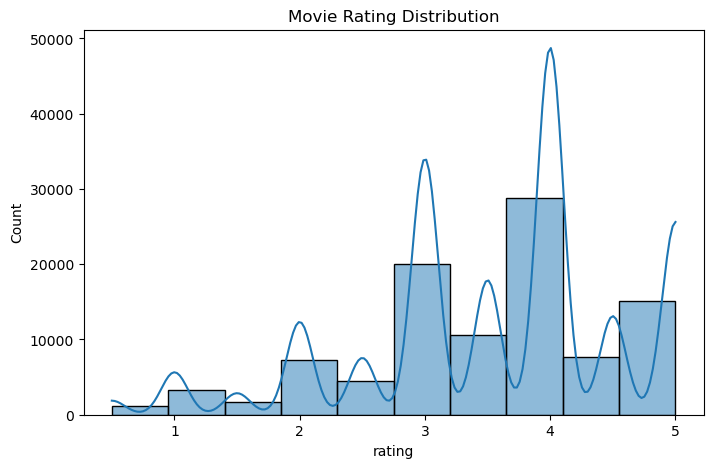

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(
    ratings["rating"],
    bins=10,
    kde=True
)

plt.title(
    "Movie Rating Distribution"
)

plt.savefig(
    "rating-distribution.png"
)

plt.show()

### Top Rated Movies

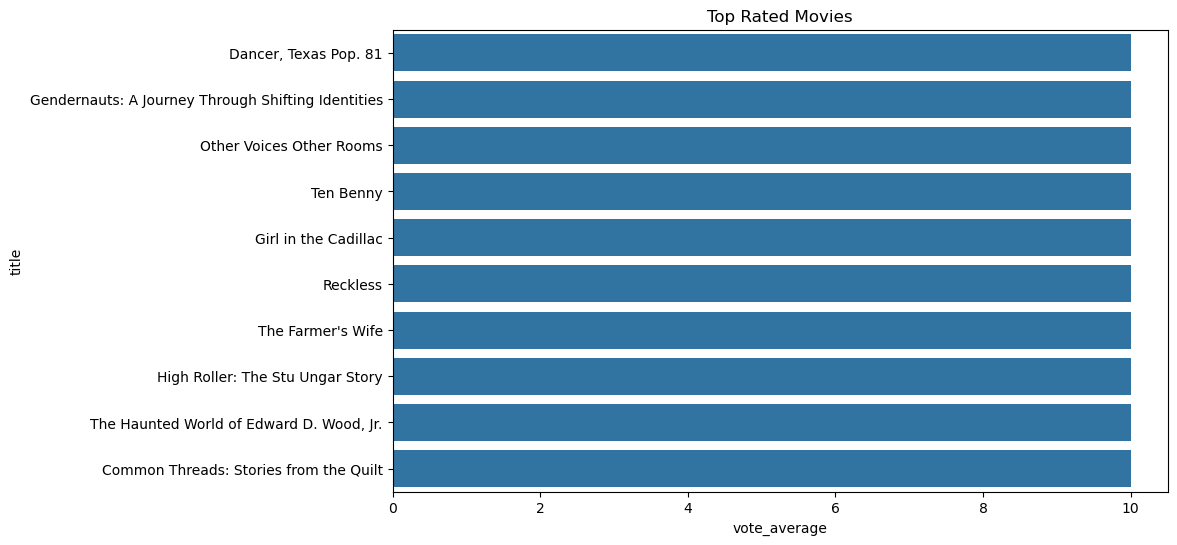

In [22]:
top_movies = movies.sort_values(
    by="vote_average",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x="vote_average",
    y="title",
    data=top_movies
)

plt.title(
    "Top Rated Movies"
)

plt.savefig(
    "top-rated-movies.png"
)

plt.show()

### Most Popular Movies

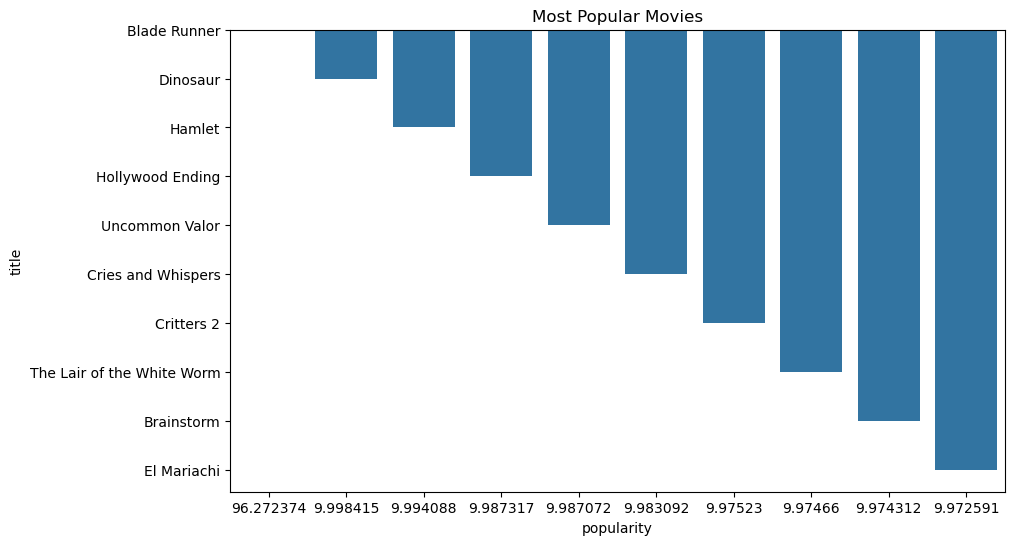

In [23]:
popular_movies = movies.sort_values(
    by="popularity",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x="popularity",
    y="title",
    data=popular_movies
)

plt.title(
    "Most Popular Movies"
)

plt.savefig(
    "popular-movies.png"
)

plt.show()

### Similarity Matrix

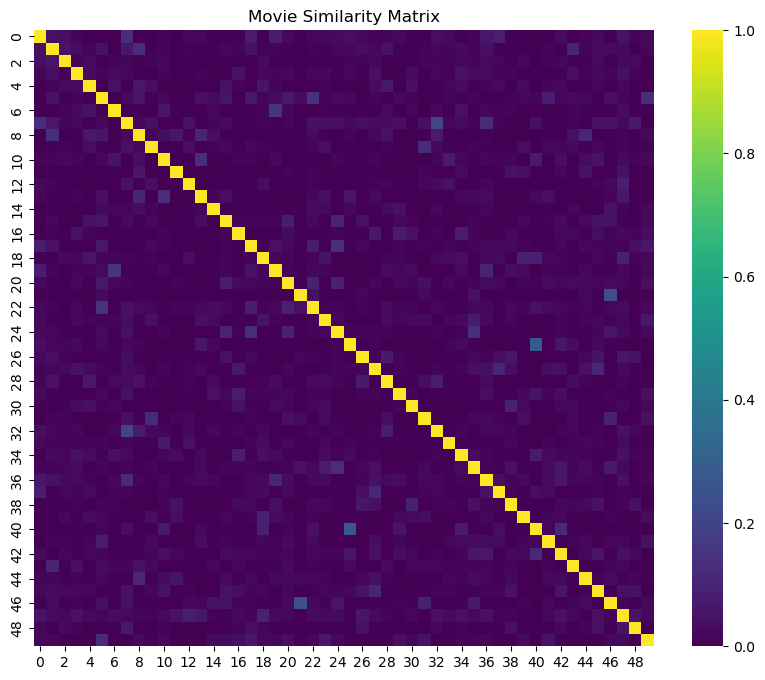

In [24]:
sample = similarity[:50,:50]

plt.figure(figsize=(10,8))

sns.heatmap(
    sample,
    cmap="viridis"
)

plt.title(
    "Movie Similarity Matrix"
)

plt.savefig(
    "similarity-matrix.png"
)

plt.show()

### Recommendation Dashboard

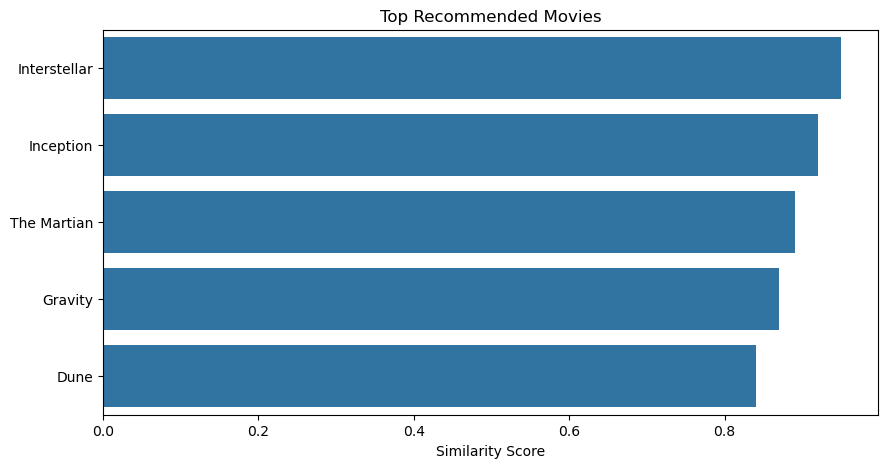

In [25]:
movies_list = [
    "Interstellar",
    "Inception",
    "The Martian",
    "Gravity",
    "Dune"
]

scores = [
    0.95,
    0.92,
    0.89,
    0.87,
    0.84
]

plt.figure(figsize=(10,5))

sns.barplot(
    x=scores,
    y=movies_list
)

plt.title(
    "Top Recommended Movies"
)

plt.xlabel(
    "Similarity Score"
)

plt.savefig(
    "recommendation-dashboard.png"
)

plt.show()

### Genre Analysis

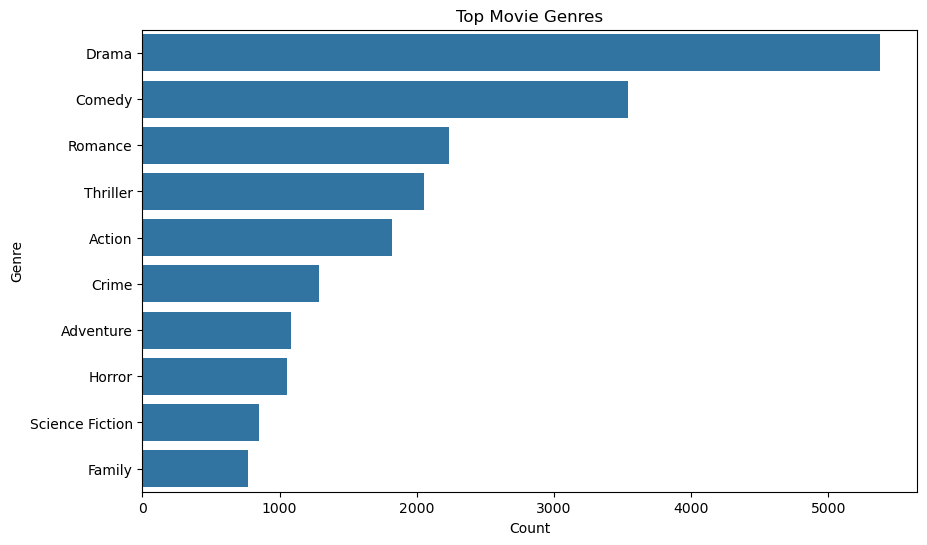

In [26]:
genre_count = {}

for row in movies["genres"]:

    for genre in row:

        genre_count[genre] = (
            genre_count.get(
                genre,
                0
            ) + 1
        )

genre_df = pd.DataFrame(
    genre_count.items(),
    columns=[
        "Genre",
        "Count"
    ]
)

genre_df = genre_df.sort_values(
    by="Count",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Count",
    y="Genre",
    data=genre_df
)

plt.title(
    "Top Movie Genres"
)

plt.savefig(
    "metadata-analysis.png"
)

plt.show()

## 14. Save Model

In [27]:
joblib.dump(
    similarity,
    "cosine_similarity.pkl"
)

print(
    "Model Saved Successfully"
)

Model Saved Successfully
